# Trabajo Práctico 3: Redes Neuronales

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd

## 1. Exploratory Analysis and Preprocessing

In [3]:
from src.utils import dataset_summary, train_and_evaluate_model, advanced_comparison_table, print_training_summary, results_table
from src.graphics import plot_class_distribution, plot_images, plot_loss_history, plot_confusion_matrix
from src.data_splitting import train_val_test_split, split_summary
from src.preprocessing import normalize_image
from src.models import MLP
from src.metrics import evaluate_model, performance_report_table

In [4]:
X_img = np.load("Datos/X_images.npy")
y_img = np.load("Datos/y_images.npy")

### a) Exploratory Data Analysis

Dataset summary
----------------------------------------
Number of images: 809555
X shape: (809555, 28, 28)
y shape: (809555,)
X dtype: uint8
y dtype: uint8

Pixel values
----------------------------------------
Minimum: 0
Maximum: 255
Approximate mean: 44.1255
Approximate standard deviation: 84.4519
Statistics computed on 10000 images

Classes
----------------------------------------
Number of classes: 47
Classes found: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46]

Dataset balance
----------------------------------------
Smallest class: Class 40 (2861 images)
Largest class: Class 1 (44604 images)
Max/min ratio: 15.59


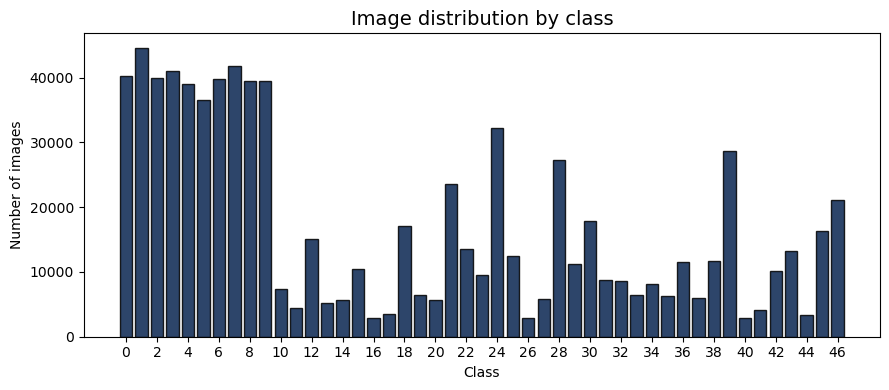

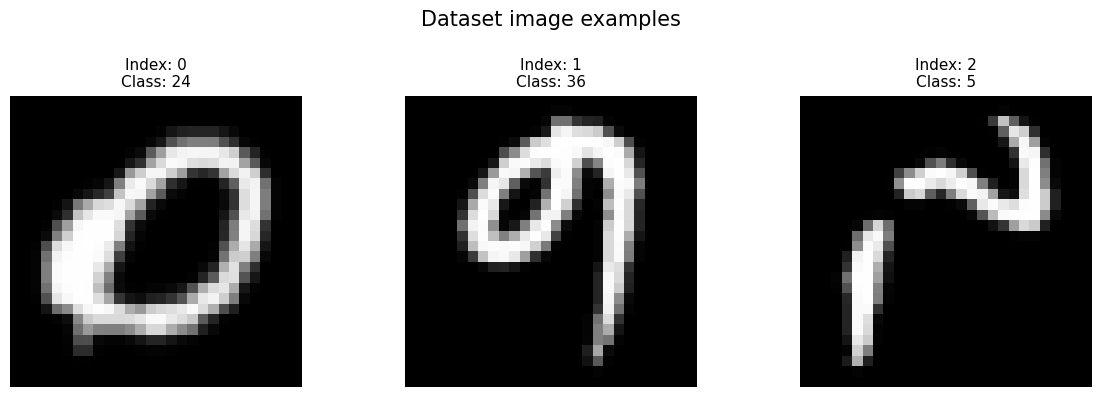

: 

In [ ]:
clases, cantidades = dataset_summary(X_img, y_img)
plot_class_distribution(clases, cantidades)

plot_images(X_img, y_img)

### b) Data Splitting

In [ ]:
train, val, test = train_val_test_split(X_img, y_img)
split_summary(train, val, test)

### c) Normalizing

In [ ]:
xtr, ytr = train
xval, yval = val
xtest, ytest = test

In [ ]:
n_train = 100
n_val = 10
n_test = 10

# n_train = xtr.shape[0]
# n_val = xval.shape[0]
# n_test = xtest.shape[0]
n_classes = len(np.unique(y_img))

xtr_sample = xtr[:n_train]
xval_sample = xval[:n_val]
xtest_sample = xtest[:n_test]

ytr_sample = ytr[:n_train]
yval_sample = yval[:n_val]
ytest_sample = ytest[:n_test]

xtr_norm = normalize_image(xtr_sample).reshape(n_train, -1)
xval_norm = normalize_image(xval_sample).reshape(n_val, -1)
xtest_norm = normalize_image(xtest_sample).reshape(n_test, -1)

## 2. Basic Neural Network

### c) M0

In [ ]:
M0 = MLP(input_size = 28 * 28, hidden_size = 2, hidden_nodes = [128, 64],
         output_size = n_classes, full_batch_chunk_size = 50)

In [ ]:
history_M0 = M0.fit(xtr_norm, ytr_sample, X_val = xval_norm, y_val = yval_sample,
    epochs = 100, verbose = False)

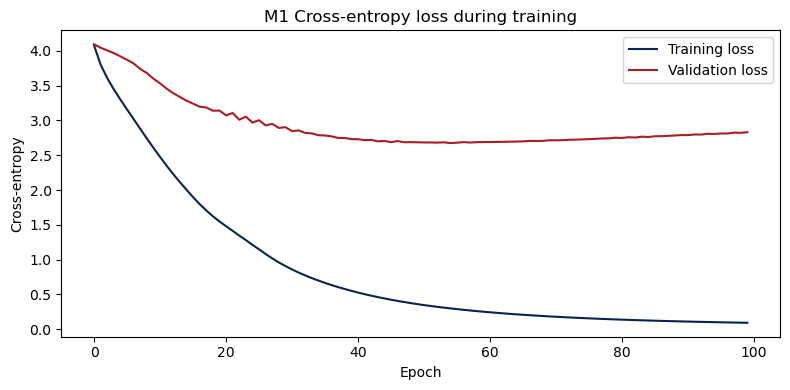

In [ ]:
plot_loss_history(history_M0)

### d) Metrics

In [ ]:
train_results_M0 = evaluate_model(M0, xtr_norm, ytr_sample, n_classes)
val_results_M0 = evaluate_model(M0, xval_norm, yval_sample, n_classes)

In [ ]:
print_training_summary("M0", history_M0, train_results_M0, val_results_M0)


M0 summary
------------------------------------------------------------
Epochs trained: 100
Updates: 100
Batches per epoch: 1
Chunks per epoch: 2
Average epoch time: 0.02s
Total training time: 1.82s
Final train loss: 0.0928
Final validation loss: 2.8322
Train metrics: accuracy=1.0000, cross_entropy=0.0911, f1_macro=0.6170
Validation metrics: accuracy=0.3000, cross_entropy=2.8322, f1_macro=0.0567


,Train,Validation
Accuracy,1.000,0.300
Cross-Entropy,0.091,2.832
F1-Score Macro,0.617,0.057


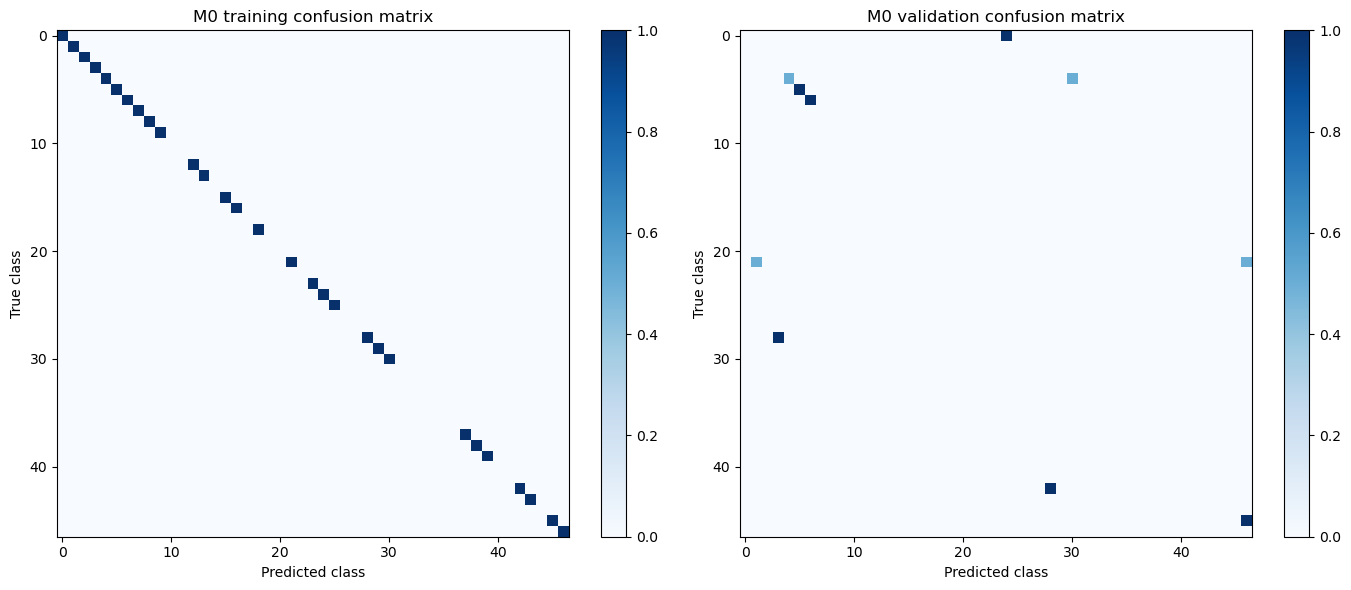

In [ ]:
performance_report_table(train_results_M0, val_results_M0)

plot_confusion_matrix(
    [
        train_results_M0["confusion_matrix"],
        val_results_M0["confusion_matrix"]
    ],
    titles = [
        "M0 training confusion matrix",
        "M0 validation confusion matrix"
    ],
)

## 3. Advanced Neural Network

Utilizaremos la misma configuracion que M1, para ver como mejora en cada caso. Se entrenará un modelo por optimización.

In [ ]:
model_config = {
    "input_size": 28 * 28,
    "hidden_size": 2,
    "hidden_nodes": [128, 64],
    "output_size": n_classes,
    "seed": 42
}

### a) Updated Models

In [ ]:
advanced_results = {}

In [ ]:
linear_schedule_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    lr_schedule = "linear",
    lr_min = 1e-4
)

advanced_results["Linear schedule"] = train_and_evaluate_model(
    linear_schedule_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)


Model summary
------------------------------------------------------------
Epochs trained: 70
Updates: 70
Batches per epoch: 1
Chunks per epoch: 1
Average epoch time: 0.01s
Total training time: 0.39s
Final train loss: 3.3596
Final validation loss: 3.9944
Train metrics: accuracy=0.2300, cross_entropy=3.3595, f1_macro=0.0587
Validation metrics: accuracy=0.0000, cross_entropy=3.9944, f1_macro=0.0000


In [ ]:
exponential_schedule_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    lr_schedule = "exponential",
    lr_decay = 0.95,
    lr_min = 1e-4
)

advanced_results["Exponential schedule"] = train_and_evaluate_model(
    exponential_schedule_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)


Model summary
------------------------------------------------------------
Epochs trained: 70
Updates: 70
Batches per epoch: 1
Chunks per epoch: 1
Average epoch time: 0.00s
Total training time: 0.34s
Final train loss: 3.6127
Final validation loss: 4.0616
Train metrics: accuracy=0.1300, cross_entropy=3.6121, f1_macro=0.0455
Validation metrics: accuracy=0.0000, cross_entropy=4.0616, f1_macro=0.0000


In [ ]:
mini_batch_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd"
)

advanced_results["Mini-batch SGD"] = train_and_evaluate_model(
    mini_batch_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = 256
)


Model summary
------------------------------------------------------------
Epochs trained: 70
Updates: 70
Batches per epoch: 1
Chunks per epoch: 1
Average epoch time: 0.00s
Total training time: 0.32s
Final train loss: 2.8533
Final validation loss: 3.8144
Train metrics: accuracy=0.3200, cross_entropy=2.8392, f1_macro=0.0892
Validation metrics: accuracy=0.1000, cross_entropy=3.8144, f1_macro=0.0142


In [ ]:
adam_model = MLP(
    **model_config,
    learning_rate = 0.001,
    optimizer = "adam"
)

advanced_results["Adam"] = train_and_evaluate_model(
    adam_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)


Model summary
------------------------------------------------------------
Epochs trained: 70
Updates: 70
Batches per epoch: 1
Chunks per epoch: 1
Average epoch time: 0.01s
Total training time: 0.61s
Final train loss: 0.0260
Final validation loss: 3.1730
Train metrics: accuracy=1.0000, cross_entropy=0.0250, f1_macro=0.6170
Validation metrics: accuracy=0.3000, cross_entropy=3.1730, f1_macro=0.0567


In [ ]:
l2_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    l2_lambda = 0.001
)

advanced_results["L2"] = train_and_evaluate_model(
    l2_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)


Model summary
------------------------------------------------------------
Epochs trained: 70
Updates: 70
Batches per epoch: 1
Chunks per epoch: 1
Average epoch time: 0.01s
Total training time: 0.46s
Final train loss: 2.8558
Final validation loss: 3.8384
Train metrics: accuracy=0.3200, cross_entropy=2.8392, f1_macro=0.0892
Validation metrics: accuracy=0.1000, cross_entropy=3.8143, f1_macro=0.0142


In [ ]:
early_stopping_model = MLP(
    **model_config,
    learning_rate = 0.01,
    optimizer = "gd",
    early_stopping = True,
    patience = 5,
    min_delta = 1e-4
)

advanced_results["Early stopping"] = train_and_evaluate_model(
    early_stopping_model,
    xtr_norm,
    ytr_sample,
    xval_norm,
    yval_sample,
    n_classes,
    epochs = 70,
    batch_size = None
)


Model summary
------------------------------------------------------------
Epochs trained: 70
Updates: 70
Batches per epoch: 1
Chunks per epoch: 1
Average epoch time: 0.00s
Total training time: 0.30s
Final train loss: 2.8533
Final validation loss: 3.8144
Train metrics: accuracy=0.3200, cross_entropy=2.8392, f1_macro=0.0892
Validation metrics: accuracy=0.1000, cross_entropy=3.8144, f1_macro=0.0142


Model,Epochs,Updates,Batches/Epoch,Chunks/Epoch,Avg. Epoch Time (s),Total Time (s),Train Accuracy,Val. Accuracy,Train Cross-Entropy,Val. Cross-Entropy,Train F1,Val. F1
Linear schedule,70,70,1,1,0.01,0.39,0.23,0.00,3.36,3.99,0.06,0.00
Exponential schedule,70,70,1,1,0.00,0.34,0.13,0.00,3.61,4.06,0.05,0.00
Mini-batch SGD,70,70,1,1,0.00,0.32,0.32,0.10,2.84,3.81,0.09,0.01
Adam,70,70,1,1,0.01,0.61,1.00,0.30,0.02,3.17,0.62,0.06
L2,70,70,1,1,0.01,0.46,0.32,0.10,2.84,3.81,0.09,0.01
Early stopping,70,70,1,1,0.00,0.30,0.32,0.10,2.84,3.81,0.09,0.01


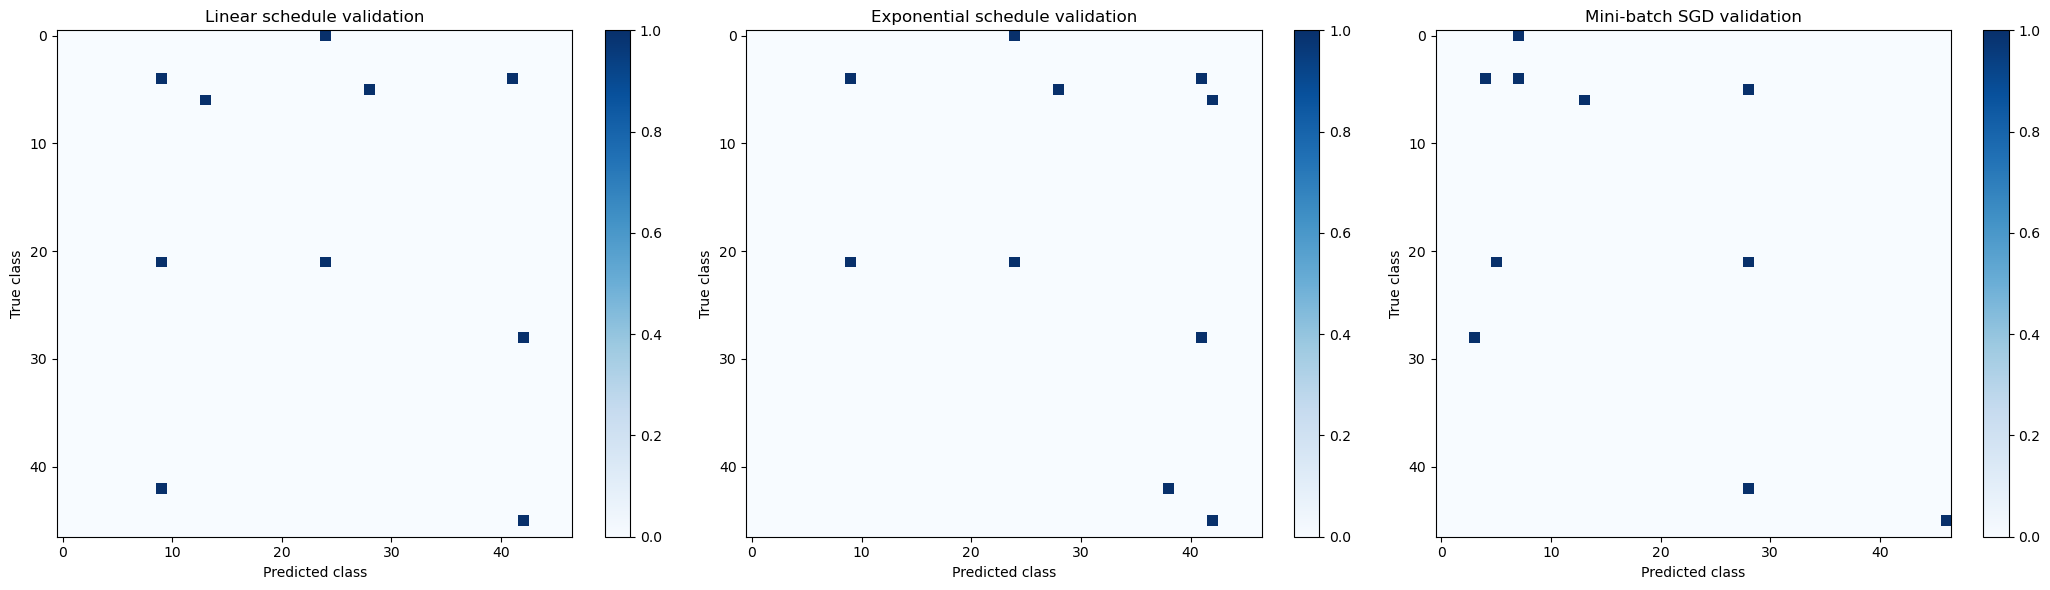

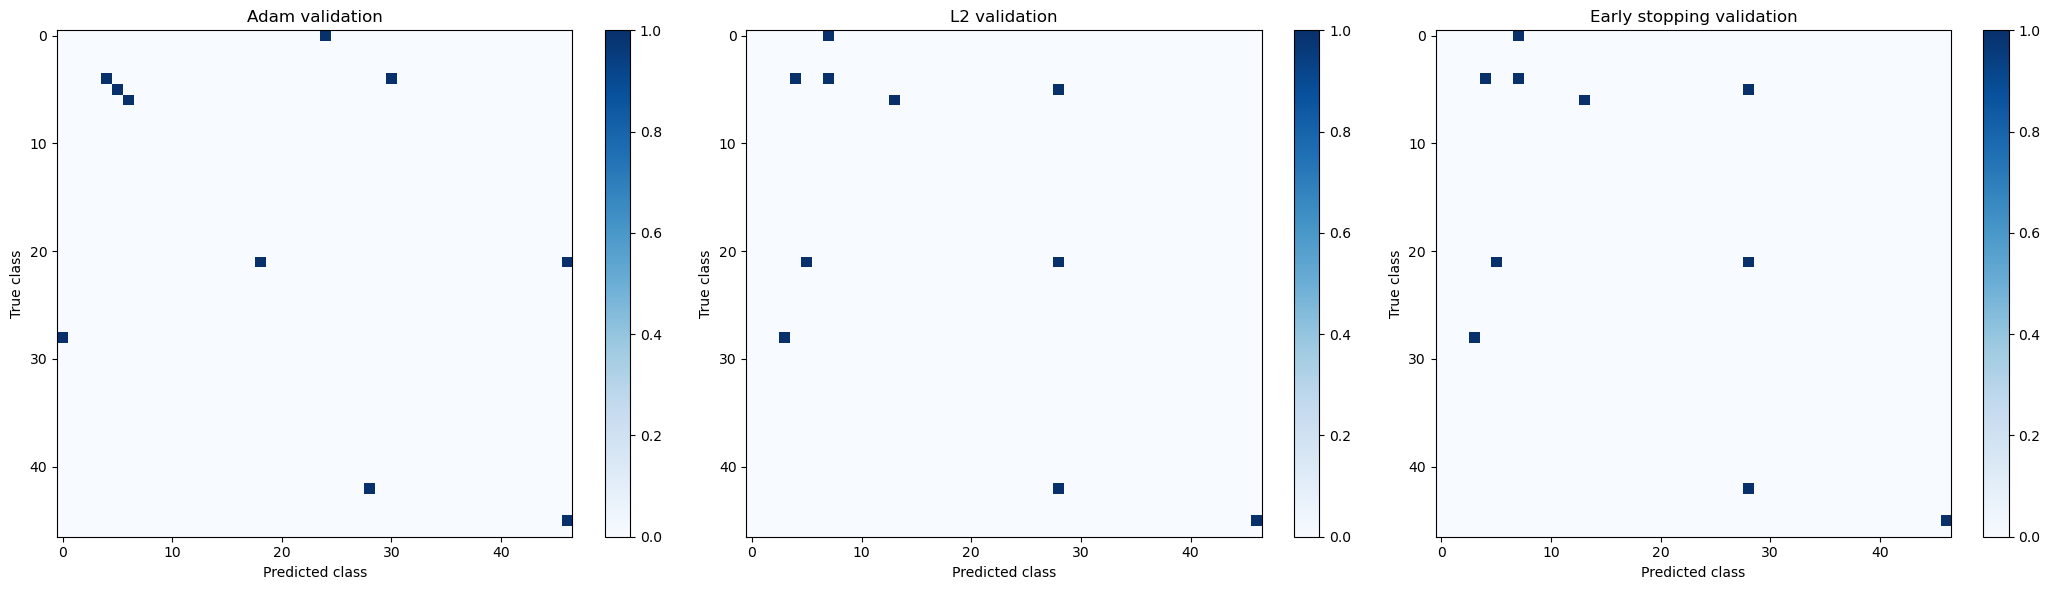

In [ ]:
advanced_comparison_table(advanced_results)

confusion_matrix = []
titles = []

for model_name, results in advanced_results.items():
    confusion_matrix.append(results["val_metrics"]["confusion_matrix"])
    titles.append(f"{model_name} validation")

selected_models = [
    "Linear schedule",
    "Exponential schedule",
    "Mini-batch SGD"
]

plot_confusion_matrix(
    [advanced_results[name]["val_metrics"]["confusion_matrix"] for name in selected_models],
    titles = [f"{name} validation" for name in selected_models],
)

selected_models = [
    "Adam",
    "L2",
    "Early stopping"
]

plot_confusion_matrix(
    [advanced_results[name]["val_metrics"]["confusion_matrix"] for name in selected_models],
    titles = [f"{name} validation" for name in selected_models],
)


### b) Looking for M1

In [ ]:
from src.grid_search import grid_search

Vamos a combinar el mejor modelo con el resto de optimizaciones posibles. Para la combinacion de mejor performance, se realizará un grid search sobre sus hiperparámetros.
uso adam, early stopping, minibatch, l2, debido a sus val accuracy y val F1

##### M1

In [ ]:
param_grid = {
    "input_size": [28 * 28],
    "hidden_size": [2],
    "hidden_nodes": [
        [256, 128, 5],
        [128, 64],
        [256, 128],
    ],
    "output_size": [n_classes],
    "learning_rate": [0.01, 0.001],
    "optimizer": ["adam"],
    "beta1": [0.9, 0.95],
    "beta2": [0.999],
    "l2_lambda": [0.001, 0.01],
    "early_stopping": [True],
    "patience": [5, 10],
    "seed": [42]
}

: 

In [ ]:
M1, best_params, best_score, results = grid_search(MLP, param_grid, xtr_norm, ytr_sample, xval_norm,
                                                       yval_sample, epochs = 50, batch_size = 256, verbose=True)

In [ ]:
M1_history = None

for result in results:
    if result["model"] is M1:
        M1_history = result["history"]
        break

epochs_M1 = M1_history["epochs_trained"]

In [ ]:
train_results_M1 = evaluate_model(M1, xtr_norm, ytr_sample, n_classes)
val_results_M1 = evaluate_model(M1, xval_norm, yval_sample, n_classes)

In [ ]:
best_result_table = pd.DataFrame({
    "Item": ["Best validation loss", "Best parameters"],
    "Value": [best_score, best_params]
})

display(
    best_result_table.style
    .hide(axis = "index")
)

performance_report_table(train_results_M1, val_results_M1)
plot_loss_history(M1_history, model_name = "M1")
plot_confusion_matrix(
    [
        train_results_M1["confusion_matrix"],
        val_results_M1["confusion_matrix"]
    ],
    titles = [
        "M1 training confusion matrix",
        "M1 validation confusion matrix"
    ],
)

## 4. PyTorch Model

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from src.models import TorchMLP
from torch import nn
from src.torch_utils import train_torch_model, evaluate_torch_full_metrics
from src.graphics import plot_m1_m2_comparison, plot_final_models_comparison
from src.utils import display_final_models_table

### a) M2 and comparison with M1

##### M2

In [ ]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cpu device


In [ ]:
# Turn numpy arrays into PyTorch tensors:

X_train_tensor = torch.tensor(xtr_norm, dtype = torch.float32)
y_train_tensor = torch.tensor(ytr_sample, dtype = torch.long)

X_val_tensor = torch.tensor(xval_norm, dtype = torch.float32)
y_val_tensor = torch.tensor(yval_sample, dtype = torch.long)

X_test_tensor = torch.tensor(xtest_norm, dtype = torch.float32)
y_test_tensor = torch.tensor(ytest_sample, dtype = torch.long)

In [ ]:
# Create TensorDatsets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [ ]:
# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size = best_params["batch_size"],
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = best_params["batch_size"],
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = best_params["batch_size"],
    shuffle = False
)

In [ ]:
M2 = TorchMLP(
    input_size = best_params["input_size"],
    hidden_nodes = best_params["hidden_nodes"],
    output_size = best_params["output_size"]
).to(device)

In [ ]:
# Define the loss function
loss_fn = nn.CrossEntropyLoss()

In [ ]:
# define teh optimizer based on M1 parameters

if best_params["optimizer"] == "adam":
    optimizer = torch.optim.Adam(
        M2.parameters(),
        lr = best_params["learning_rate"],
        weight_decay = best_params["l2_lambda"]
    )
else:
    optimizer = torch.optim.SGD(
        M2.parameters(),
        lr = best_params["learning_rate"],
        weight_decay = best_params["l2_lambda"]
    )

In [ ]:
# Train torch Model
history_M2 = train_torch_model(M2, train_loader, val_loader, loss_fn, optimizer,
                               epochs = best_params["epochs"], device = device)

In [ ]:
# Evaluate on validation set
val_results_M2 = evaluate_torch_full_metrics(M2, val_loader, n_classes, device)

##### M1 vs M2

In [ ]:
plot_m1_m2_comparison(
    {
        "M1": val_results_M1,
        "M2": val_results_M2
    }
)

### b) M3

In [ ]:
m3_param_grid = {
    "hidden_nodes": [
        [128, 64],
        [256, 128],
        [256, 128, 64],
    ],
    "activation": [
        "relu",
        "leaky_relu",
        "silu",
        "gelu"
    ],
    "dropout_rate": [
        0.0,
        0.2,
        0.4
    ]
}

In [ ]:
M3, best_m3_params, best_m3_score, m3_results = grid_search(TorchMLP, m3_param_grid, xtr_norm, ytr_sample, xval_norm,
                                                       yval_sample, epochs = 50, batch_size = 256, verbose=True)

In [ ]:
M3_history = None

for result in m3_results:
    if result["model"] is M3:
        M3_history = result["history"]
        break

In [ ]:
train_results_M3 = evaluate_torch_full_metrics(M3, train_loader, n_classes, device)
val_results_M3 = evaluate_torch_full_metrics(M3, val_loader, n_classes, device)

In [ ]:
performance_report_table(train_results_M3, val_results_M3)
plot_loss_history(M3_history, model_name = "M3")
plot_confusion_matrix(
    [
        train_results_M3["confusion_matrix"],
        val_results_M3["confusion_matrix"]
    ],
    titles = [
        "M3 training confusion matrix",
        "M3 validation confusion matrix"
    ],
)

### c) Test evaluation

In [ ]:
test_results_M0 = evaluate_model(M0, xtest_norm, ytest_sample, n_classes)
test_results_M1 = evaluate_model(M1, xtest_norm, ytest_sample, n_classes)

In [ ]:
test_results_M2 = evaluate_torch_full_metrics(M2, test_loader, n_classes, device)
test_results_M3 = evaluate_torch_full_metrics(M3, test_loader, n_classes, device)

In [ ]:
plot_final_models_comparison(test_results_M0, test_results_M1, test_results_M2, test_results_M3)
display_final_models_table(test_results_M0, test_results_M1, test_results_M2, test_results_M3)
plot_confusion_matrix(
        [
            test_results_M0["confusion_matrix"],
            test_results_M1["confusion_matrix"],

        ],
        titles = [
            "M0 - Base NumPy",
            "M1 - Best NumPy"
        ]
    )

plot_confusion_matrix(
        [
            test_results_M2["confusion_matrix"],
            test_results_M3["confusion_matrix"],

        ],
        titles = [
            "M2 - PyTorch M1",
            "M3 - Best PyTorch"
        ]
    )


### d) Testing models with noise

In [ ]:
noise_levels = [0.0, 0.05, 0.10, 0.20, 0.30]